#Author: yifan zhu
#Dataset is processed IWSLT'15 English-Vietnamese data [Small],baseline model use traditional seq2seq lstm Architure

```
#download processed dataset: https://www.kaggle.com/datasets/tuannguyenvananh/iwslt15-englishvietnamese
```



# **Date process**

(133317, 2)


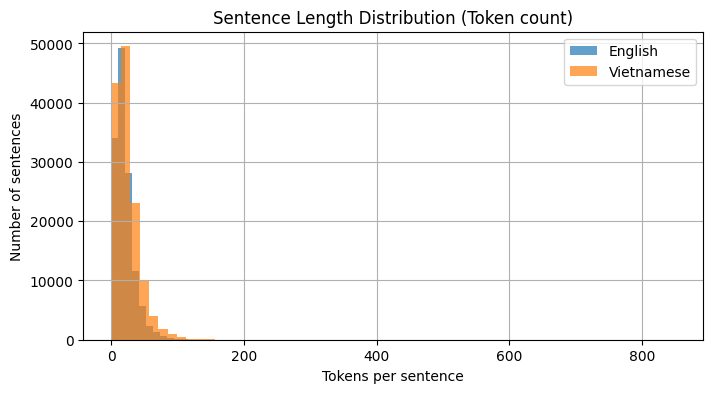

Vocab sizes: EN: 17191 | VI: 7709

**** Sample 0 ****
EN: Rachel Pike : The science behind a climate headline
EN_ids: [3, 0, 4, 5, 6, 7, 8, 9, 10]
EN_tokens: Rachel <unk> : The science behind a climate headline

VI_in : <s> Khoa học đằng sau một tiêu đề về khí hậu
VI_in_ids : [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

VI_out: Khoa học đằng sau một tiêu đề về khí hậu </s>
VI_out_ids: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 2]
encoder_input_ids         : torch.Size([32, 68])
encoder_attention_mask    : torch.Size([32, 68])
decoder_input_ids         : torch.Size([32, 68])
decoder_attention_mask    : torch.Size([32, 68])
labels                    : torch.Size([32, 68])


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from torchinfo import summary

#train data load and transfer to df format eda
train_en = "/kaggle/input/iwslt15-englishvietnamese/IWSLT'15 en-vi/train.en.txt"
train_vi = "/kaggle/input/iwslt15-englishvietnamese/IWSLT'15 en-vi/train.vi.txt"

def data_read(data_path): #data_read function read each rows
  with open(data_path, 'r', encoding='utf-8') as f:
      data_line = f.read().strip().splitlines()
  return data_line

train_en_lines = data_read(train_en)
train_vi_lines = data_read(train_vi)
assert len(train_en_lines) == len(train_vi_lines) #make sure en and vi lenth same
train_set = pd.DataFrame({"en": train_en_lines, "vi": train_vi_lines})
print(train_set.shape)

#visulization tokens distribution
train_set["en_len"] = train_set["en"].str.split().str.len()
train_set["vi_len"] = train_set["vi"].str.split().str.len()

plt.figure(figsize=(8,4))
plt.hist(train_set["en_len"], bins=60, alpha=0.7, label="English")
plt.hist(train_set["vi_len"], bins=60, alpha=0.7, label="Vietnamese")
plt.title("Sentence Length Distribution (Token count)")
plt.xlabel("Tokens per sentence")
plt.ylabel("Number of sentences")
plt.legend()
plt.grid(True)
plt.show()

#load vocab table,process word2index with inputs and target
vocab_en_path = "/kaggle/input/iwslt15-englishvietnamese/IWSLT'15 en-vi/vocab.en.txt"
vocab_vi_path = "/kaggle/input/iwslt15-englishvietnamese/IWSLT'15 en-vi/vocab.vi.txt"

def load_vocab(path):
    with open(path, encoding="utf-8") as f:
        vocab = [ln.strip() for ln in f if ln.strip()]
    w2i = {w: i for i, w in enumerate(vocab)} #构建键值对
    i2w = {i: w for i, w in enumerate(vocab)} #构建反向键值对
    return vocab, w2i, i2w

vocab_en, w2i_en, i2w_en = load_vocab(vocab_en_path)
vocab_vi, w2i_vi, i2w_vi = load_vocab(vocab_vi_path)

PAD_EN = w2i_en.get("<pad>", 0)
PAD_VI = w2i_vi.get("<pad>", 0)
UNK_EN = w2i_en.get("<unk>", 1)
UNK_VI = w2i_vi.get("<unk>", 1)
BOS_ID = w2i_vi["<s>"]      #decoder start
EOS_ID = w2i_vi["</s>"]     #decoder end

print(f"Vocab sizes: EN: {len(vocab_en)} | VI: {len(vocab_vi)}")

#tool function for word to index
def to_ids(sentence, w2i, unk_id):
    return [w2i.get(tok, unk_id) for tok in sentence.split()]

#encoder input english
train_set["src_ids"] = train_set["en"].apply(lambda s: to_ids(s, w2i_en, UNK_EN))
#decoder input Vietnamese and target Vietnamese
train_set["tgt_ids"]     = train_set["vi"].apply(lambda s: to_ids(s, w2i_vi, UNK_VI))
train_set["tgt_input"]   = train_set["tgt_ids"].apply(lambda ids: [BOS_ID] + ids)   # decoder input
train_set["tgt_output"]  = train_set["tgt_ids"].apply(lambda ids: ids + [EOS_ID])   # decoder ouput(label)

#visulization with encoder decoder input and target
sample_idx = 0  #fix check diff line pairs

src_ids = train_set["src_ids"].iloc[sample_idx]
tgt_in_ids = train_set["tgt_input"].iloc[sample_idx]
tgt_out_ids = train_set["tgt_output"].iloc[sample_idx]

def to_text(ids, id2word):
    return " ".join(id2word[i] if i in id2word else "<unk>" for i in ids)

print(f"\n**** Sample {sample_idx} ****")
print("EN:", train_set["en"].iloc[sample_idx])
print("EN_ids:", src_ids[:20])
print("EN_tokens:", to_text(src_ids, i2w_en))

print("\nVI_in :", to_text(tgt_in_ids, i2w_vi))
print("VI_in_ids :", tgt_in_ids[:20])

print("\nVI_out:", to_text(tgt_out_ids, i2w_vi))
print("VI_out_ids:", tgt_out_ids[:20])

#buid dataest and dataloader(Batch data processing)
MAX_LEN = 68

def build_fixed_tensors(df): # build tensors with fixed padding
    n = len(df)
    # init arrays
    arrays = {
        'enc': np.full((n, MAX_LEN), PAD_EN, dtype=np.int64),
        'dec': np.full((n, MAX_LEN), PAD_VI, dtype=np.int64),
        'lbl': np.full((n, MAX_LEN), -100, dtype=np.int64)
    }
    # fill arrays
    for i, r in enumerate(df.itertuples(index=False)):
        # truncate to MAX_LEN
        src, tgt_in, tgt_out = r.src_ids[:MAX_LEN], r.tgt_input[:MAX_LEN], r.tgt_output[:MAX_LEN]
        # fill non-padded positions
        arrays['enc'][i, :len(src)] = src
        arrays['dec'][i, :len(tgt_in)] = tgt_in
        arrays['lbl'][i, :len(tgt_out)] = tgt_out
        # force EOS if truncated
        if len(r.tgt_output) > MAX_LEN:
            arrays['lbl'][i, -1] = EOS_ID

    # create masks and convert to tensors
    return [torch.tensor(x) for x in [
        arrays['enc'],
        arrays['enc'] != PAD_EN,  # encoder mask
        arrays['dec'],
        arrays['dec'] != PAD_VI,  # decoder mask
        arrays['lbl']
    ]]

#split data and eval dataset
train_df, valid_df = train_test_split(train_set, test_size=0.02, random_state=42)

#create dataloaders
train_loader = DataLoader(TensorDataset(*build_fixed_tensors(train_df)),
                         batch_size=32, shuffle=True)
valid_loader = DataLoader(TensorDataset(*build_fixed_tensors(valid_df)),
                         batch_size=32, shuffle=False)

#show dataset shape
batch = next(iter(train_loader))
names = ["encoder_input_ids", "encoder_attention_mask",
         "decoder_input_ids", "decoder_attention_mask", "labels"]

for name, tensor in zip(names, batch):
    print(f"{name:25s} : {tensor.shape}")

# **Model build**

In [3]:
# bilstm encoder + Attention + lstm decoder 

VOCAB_EN = len(vocab_en)
VOCAB_VI = len(vocab_vi)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# embedding + 2 bilstm as encoder 
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=256,hidden_dim=256, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(
            emb_dim, hidden_dim // 2,batch_first=True, 
            dropout=dropout, bidirectional=True, num_layers=2
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(self.embedding(x))                # [B, Ls, E]
        outputs, (h, c) = self.rnn(x)                      # outputs: [B, Ls, H]
        h = torch.cat((h[-2], h[-1]), dim=1).unsqueeze(0)  # [1, B, H]
        c = torch.cat((c[-2], c[-1]), dim=1).unsqueeze(0)  # [1, B, H]
        return outputs, (h, c)


# attention pooling with mask padding 
class LuongAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.linear_in = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, dec_out, enc_out, enc_pad_mask=None):
        query = self.linear_in(dec_out)                          # [B, Lt, H]
        scores = torch.bmm(query, enc_out.transpose(1, 2))       # [B, Lt, Ls]

        if enc_pad_mask is not None:
            #If a sample sentence is entirely PAD, at least the first position is retained to avoid blocking the entire line.
            all_pad = enc_pad_mask.all(dim=1)                    # [B]
            if all_pad.any():
                enc_pad_mask = enc_pad_mask.clone()
                enc_pad_mask[all_pad, 0] = False

            scores = scores.masked_fill(enc_pad_mask.unsqueeze(1), -1e9)

        # softmax before transfer to fp32 
        attn = F.softmax(scores.float(), dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)

        context = torch.bmm(attn, enc_out)                       # [B, Lt, H]
        return context


# embeeding + 1 lstm + attention as decoder
class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden_dim=256, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, batch_first=True,num_layers=1)
        self.attn = LuongAttention(hidden_dim)
        self.linear = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, dec_in, enc_out, state, enc_pad_mask=None):
        x = self.dropout(self.embedding(dec_in))                 # [B, Lt, E]
        dec_out, _ = self.rnn(x, state)                          # [B, Lt, H]
        context = self.attn(dec_out, enc_out, enc_pad_mask)      # 传入mask
        concat = torch.cat([dec_out, context], dim=-1)           # [B, Lt, 2H]
        logits = self.linear(self.dropout(concat))               # [B, Lt, V]
        return logits


# combine encoder with decoder
class Seq2SeqAttn(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder(VOCAB_EN, 256, 256, pad_idx=PAD_EN)
        self.decoder = DecoderWithAttention(VOCAB_VI, 256, 256, pad_idx=PAD_VI)

    def forward(self, enc_in, dec_in):
        enc_out, enc_state = self.encoder(enc_in)
        enc_pad_mask = (enc_in == PAD_EN)                        # [B, Ls]
        logits = self.decoder(dec_in, enc_out, enc_state, enc_pad_mask)
        return logits

    #Convert logit to actual sentence
    @torch.no_grad()
    def greedy_decode(self, enc_in, max_len=68, bos_id=BOS_ID, eos_id=EOS_ID):
        self.eval()
        enc_out, enc_state = self.encoder(enc_in)
        enc_pad_mask = (enc_in == PAD_EN)                        # [B, Ls]
        B = enc_in.size(0)
        cur = torch.full((B, 1), bos_id, dtype=torch.long, device=enc_in.device)
        outputs = []
        for _ in range(max_len):
            logits = self.decoder(cur, enc_out, enc_state, enc_pad_mask)
            next_ids = logits[:, -1, :].argmax(-1, keepdim=True)
            outputs.append(next_ids)
            cur = torch.cat([cur, next_ids], dim=1)
            if (next_ids.squeeze(1) == eos_id).all():
                break
        return torch.cat(outputs, dim=1)


# ---------------- Instantiate ----------------
model = Seq2SeqAttn().to(device)
summary(model, input_data=(torch.randint(0, VOCAB_EN, (32, 68)).to(device),
                           torch.randint(0, VOCAB_VI, (32, 68)).to(device)))

Layer (type:depth-idx)                   Output Shape              Param #
Seq2SeqAttn                              [32, 68, 7709]            --
├─Encoder: 1-1                           [32, 68, 256]             --
│    └─Embedding: 2-1                    [32, 68, 256]             4,400,896
│    └─Dropout: 2-2                      [32, 68, 256]             --
│    └─LSTM: 2-3                         [32, 68, 256]             790,528
├─DecoderWithAttention: 1-2              [32, 68, 7709]            --
│    └─Embedding: 2-4                    [32, 68, 256]             1,973,504
│    └─Dropout: 2-5                      [32, 68, 256]             --
│    └─LSTM: 2-6                         [32, 68, 256]             526,336
│    └─LuongAttention: 2-7               [32, 68, 256]             --
│    │    └─Linear: 3-1                  [32, 68, 256]             65,536
│    └─Dropout: 2-8                      [32, 68, 512]             --
│    └─Linear: 2-9                       [32, 68, 7709]  

# **train and eval**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.5 MB/s eta 0:00:00
Epoch 1: train=4.1718  valid=3.3167
[SacreBLEU] BLEU = 11.24
Epoch 2: train=3.2259  valid=2.8271
[SacreBLEU] BLEU = 16.41


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 3: train=2.9045  valid=2.6429
[SacreBLEU] BLEU = 19.21
Epoch 4: train=2.7444  valid=2.5420
[SacreBLEU] BLEU = 20.69
Epoch 5: train=2.6447  valid=2.4771
[SacreBLEU] BLEU = 21.01
Epoch 6: train=2.5710  valid=2.4301
[SacreBLEU] BLEU = 21.26
Epoch 7: train=2.5111  valid=2.3994
[SacreBLEU] BLEU = 22.70
Epoch 8: train=2.4555  valid=2.3644
[SacreBLEU] BLEU = 22.26
Epoch 9: train=2.4053  valid=2.3416
[SacreBLEU] BLEU = 22.72
Epoch 10: train=2.3572  valid=2.3119
[SacreBLEU] BLEU = 24.00
Epoch 11: train=2.3115  valid=2.2954
[SacreBLEU] BLEU = 24.34
Epoch 12: train=2.2719  valid=2.2820
[SacreBLEU] BLEU = 24.76
Epoch 13: train=2.2369  valid=2.2722
[SacreBLEU] BLEU = 24.51
Epoch 14: train=2.2121  valid=2.2673
[SacreBLEU] BLEU = 25.01
Epoch 15: train=2.1957  valid=2.2651
[SacreBLEU] BLEU = 24.84


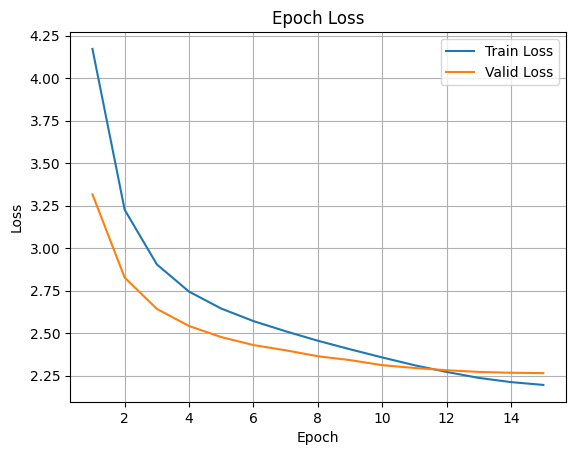

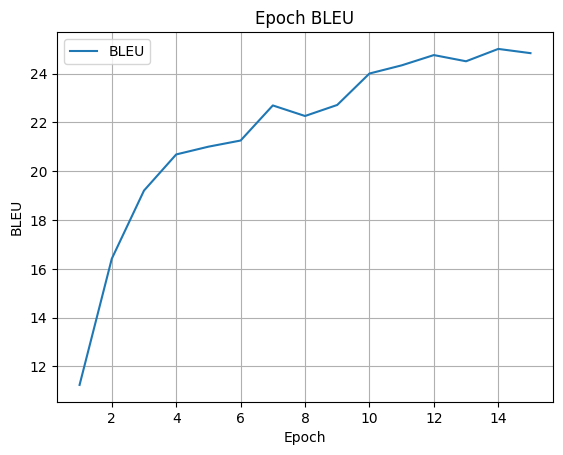

In [3]:
# pip metric
!pip install sacrebleu

# loss use CrossEntropyLoss, optimizer use adam with weight decay  
criterion = nn.CrossEntropyLoss(ignore_index=-100) 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# lr Scheduler: 2 linear warmup,other cosineannealing 
from torch.optim.lr_scheduler import ConstantLR, CosineAnnealingLR, SequentialLR

total_epochs = 15
warm_epochs = 2            # 前 3 个 epoch 常数学习率
eta_min = 1e-5             # 余弦最低学习率，可按需调整

scheduler = SequentialLR(
    optimizer,
    schedulers=[
        ConstantLR(optimizer, factor=1.0, total_iters=warm_epochs),                       # 固定 LR
        CosineAnnealingLR(optimizer, T_max=total_epochs - warm_epochs, eta_min=eta_min)   # 余弦退火
    ],
    milestones=[warm_epochs]
)

#train loop
def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    for batch in loader:
        enc_in, _, dec_in, _, labels = [t.to(device).long() for t in batch]
        logits = model(enc_in, dec_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_one_epoch(loader):
    model.eval()
    total_loss = 0.0
    for batch in loader:
        enc_in, _, dec_in, _, labels = [t.to(device).long() for t in batch]
        logits = model(enc_in, dec_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)


#tool function transfer ids to text
def ids_to_text(ids, id2word, bos_id=BOS_ID, eos_id=EOS_ID, pad_id=PAD_VI):
    if ids.dim() == 1:
        ids = ids.unsqueeze(0)
    texts = []
    for seq in ids.tolist():
        toks = []
        for t in seq:
            if t in (bos_id, pad_id):
                continue
            if t == eos_id:
                break
            toks.append(id2word.get(t, "<unk>"))
        texts.append(" ".join(toks))
    return texts


# BLEU eval
@torch.no_grad()
def evaluate_bleu(valid_loader, max_batches=5):
    import sacrebleu
    model.eval()
    preds, refs = [], []
    for i, batch in enumerate(valid_loader):
        enc_in, _, dec_in, _, labels = [t.to(device).long() for t in batch]
        pred_ids = model.greedy_decode(enc_in, max_len=dec_in.size(1))
        preds.extend(ids_to_text(pred_ids, i2w_vi))
        for seq in labels.cpu():
            toks = [i2w_vi[t] for t in seq.tolist() if t not in (-100, EOS_ID)]
            refs.append(" ".join(toks))
        if i + 1 >= max_batches:
            break
    bleu = sacrebleu.corpus_bleu(preds, [refs], force=True).score
    print(f"[SacreBLEU] BLEU = {bleu:.2f}")
    return bleu


# =========================
# train 15 epoches and print fit curve 
train_losses, valid_losses, bleu_scores = [], [], []

for epoch in range(total_epochs):
    tr = train_one_epoch(train_loader)
    va = eval_one_epoch(valid_loader)
    train_losses.append(tr)
    valid_losses.append(va)

    print(f"Epoch {epoch+1}: train={tr:.4f}  valid={va:.4f}")

    bleu = evaluate_bleu(valid_loader, max_batches=8)
    bleu_scores.append(bleu)
    scheduler.step()


# 1) Loss curve
plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1, len(valid_losses)+1), valid_losses, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2) BLEU curve
plt.figure()
plt.plot(range(1, len(bleu_scores)+1), bleu_scores, label="BLEU")
plt.xlabel("Epoch")
plt.ylabel("BLEU")
plt.title("Epoch BLEU")
plt.legend()
plt.grid(True)
plt.show()


#save model
SAVE_PATH = "seq2seq_attn_en_vi.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "w2i_en": w2i_en,
    "i2w_en": i2w_en,
    "w2i_vi": w2i_vi,
    "i2w_vi": i2w_vi,
    "PAD_EN": PAD_EN,
    "PAD_VI": PAD_VI,
    "UNK_EN": UNK_EN,
    "UNK_VI": UNK_VI,
    "BOS_ID": BOS_ID,
    "EOS_ID": EOS_ID,
}, SAVE_PATH)



In [6]:
# test model in test2013
!pip install sacrebleu
import os, torch
import sacrebleu

# paths
CKPT_PATH = "/kaggle/input/lab2-models/seq2seq_attn_en_vi.pt"  
TEST_EN   = "/kaggle/input/iwslt15-englishvietnamese/IWSLT'15 en-vi/tst2013.en.txt"
TEST_VI   = "/kaggle/input/iwslt15-englishvietnamese/IWSLT'15 en-vi/tst2013.vi.txt"

assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
assert os.path.exists(TEST_EN),   f"Test EN not found: {TEST_EN}"
assert os.path.exists(TEST_VI),   f"Test VI not found: {TEST_VI}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load checkpoint
ckpt = torch.load(CKPT_PATH, map_location=device)
w2i_en, i2w_en = ckpt["w2i_en"], ckpt["i2w_en"]
w2i_vi, i2w_vi = ckpt["w2i_vi"], ckpt["i2w_vi"]

PAD_EN, PAD_VI = ckpt["PAD_EN"], ckpt["PAD_VI"]
UNK_EN, UNK_VI = ckpt["UNK_EN"], ckpt["UNK_VI"]
BOS_ID, EOS_ID = ckpt["BOS_ID"], ckpt["EOS_ID"]

VOCAB_EN = len(w2i_en)
VOCAB_VI = len(w2i_vi)
MAX_LEN  = 68

model = Seq2SeqAttn().to(device)
model.load_state_dict(ckpt["model_state_dict"], strict=True)
model.eval()
print("Model & vocab restored and loaded (strict).")

def read_lines(path):
    with open(path, encoding="utf-8") as f:
        return [ln.strip() for ln in f if ln.strip()]

def encode_en(sentence, w2i, unk_id=UNK_EN, max_len=MAX_LEN):
    ids = [w2i.get(tok, unk_id) for tok in sentence.split()]
    ids = ids[:max_len]
    ids += [PAD_EN] * (max_len - len(ids))
    return torch.tensor([ids], dtype=torch.long, device=device)

def ids_to_vi_text(ids_tensor, i2w, bos_id=BOS_ID, eos_id=EOS_ID, pad_id=PAD_VI):
    toks = []
    for t in ids_tensor[0].tolist():
        if t in (bos_id, pad_id):
            continue
        if t == eos_id:
            break
        toks.append(i2w.get(t, "<unk>"))
    return " ".join(toks)

# 5) read test file and inference 
en_lines = read_lines(TEST_EN)
vi_refs  = read_lines(TEST_VI)
assert len(en_lines) == len(vi_refs), "EN/VI test size mismatch!"

preds = []
for src in en_lines:
    enc = encode_en(src, w2i_en, unk_id=UNK_EN, max_len=MAX_LEN)
    pred_ids = model.greedy_decode(enc, max_len=MAX_LEN, bos_id=BOS_ID, eos_id=EOS_ID)
    pred_text = ids_to_vi_text(pred_ids, i2w_vi, BOS_ID, EOS_ID, PAD_VI)
    preds.append(pred_text)

#print top3
print("\ntest2013: Top 3 predict")
for i in range(min(3, len(en_lines))):
    print(f"\n[EN ] {en_lines[i]}")
    print(f"[REF] {vi_refs[i]}")
    print(f"[PRD] {preds[i]}")

#calculate SacreBLEU
bleu = sacrebleu.corpus_bleu(preds, [vi_refs], force=True).score
print(f"\n[SacreBLEU] tst2013 BLEU = {bleu:.2f}")


Model & vocab restored and loaded (strict).

test2013: Top 3 predict

[EN ] When I was little , I thought my country was the best on the planet , and I grew up singing a song called &quot; Nothing To Envy . &quot;
[REF] Khi tôi còn nhỏ , Tôi nghĩ rằng BắcTriều Tiên là đất nước tốt nhất trên thế giới và tôi thường hát bài &quot; Chúng ta chẳng có gì phải ghen tị . &quot;
[PRD] Khi tôi còn nhỏ , tôi nghĩ đất nước tôi là tốt nhất trên hành tinh , và tôi lớn lên hát một bài hát tên là &quot; Không có gì để làm . &quot;

[EN ] And I was very proud .
[REF] Tôi đã rất tự hào về đất nước tôi .
[PRD] Và tôi rất tự hào .

[EN ] In school , we spent a lot of time studying the history of Kim Il-Sung , but we never learned much about the outside world , except that America , South Korea , Japan are the enemies .
[REF] Ở trường , chúng tôi dành rất nhiều thời gian để học về cuộc đời của chủ tịch Kim II- Sung , nhưng lại không học nhiều về thế giới bên ngoài , ngoại trừ việc Hoa Kỳ , Hàn Quốc và Nhật